In [1]:
!pip install cake-ensemble

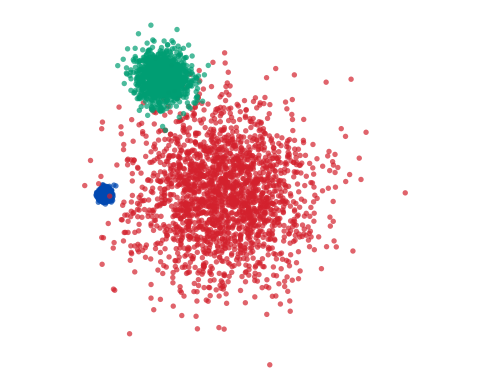

Filtering applied: Kept 2800 out of 4000 points.

=== Average Clustering Performance (10 runs) ===
Full     Data -> ARI: 0.593 | NMI: 0.660 | AMI: 0.660 | ACC: 0.782 | SIL: 0.537
Cleaned  Data -> ARI: 0.908 | NMI: 0.879 | AMI: 0.879 | ACC: 0.966 | SIL: 0.805


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, accuracy_score,
                             silhouette_score, confusion_matrix)
from cake_ensemble import cake

# 1. Generate synthetic data (3 distinct clusters with varying densities)
centers, stds, sizes = [[0, 0], [8, 0], [4, 8]], [0.2, 3.0, 1.0], [1000, 2000, 1000]
X_list, y_list = [], []
for i in range(3):
    Xi, _ = make_blobs(n_samples=sizes[i],
                       centers=[centers[i]],
                       cluster_std=stds[i],
                       random_state=100+i)
    X_list.append(Xi); y_list.extend([i] * sizes[i])
X, y = np.vstack(X_list), np.array(y_list)

# 2. Visualize the original dataset
PALETTE = ["#0048B1", "#D3212D", "#009E73"]
plt.figure(figsize=(5, 4))
for i in range(3):
    plt.scatter(X[y==i, 0], X[y==i, 1], c=PALETTE[i], s=15, alpha=0.7, edgecolors='none')
plt.axis('equal'); plt.axis('off'); plt.tight_layout(); plt.show()

# 3. Create a KMeans ensemble and compute pointwise CAKE scores
ensemble = [KMeans(
        n_clusters=3,
        init='random',
        n_init=1,
        random_state=s
).fit_predict(X) for s in range(20)]
cake_scores, _, _, _ = cake(X, ensemble, method='product')

# 4. Filter the dataset (drop the lowest-scoring 30% of points)
keep_mask = cake_scores > np.percentile(cake_scores, 30)
X_clean, y_clean = X[keep_mask], y[keep_mask]
print(f"Filtering applied: Kept {len(X_clean)} out of {len(X)} points.\n")

# Helper to calculate true clustering accuracy via Hungarian label alignment
def cluster_acc(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row, col = linear_sum_assignment(cm.max() - cm)
    aligned = np.zeros_like(y_pred)
    for t, p in zip(row, col): aligned[y_pred == p] = t
    return accuracy_score(y_true, aligned)

# 5. Evaluate standard KMeans on both datasets across 10 trials
metrics = ['ARI', 'NMI', 'AMI', 'ACC', 'SIL']
res = {'Full': {m: [] for m in metrics}, 'Cleaned': {m: [] for m in metrics}}

for seed in range(10):
    km = KMeans(n_clusters=3, init="random", n_init=1, random_state=seed)

    # Evaluate on Full Data
    p_full = km.fit_predict(X)
    res['Full']['ARI'].append(adjusted_rand_score(y, p_full))
    res['Full']['NMI'].append(normalized_mutual_info_score(y, p_full))
    res['Full']['AMI'].append(adjusted_mutual_info_score(y, p_full))
    res['Full']['ACC'].append(cluster_acc(y, p_full))
    res['Full']['SIL'].append(silhouette_score(X, p_full))

    # Evaluate on Cleaned Data
    p_clean = km.fit_predict(X_clean)
    res['Cleaned']['ARI'].append(adjusted_rand_score(y_clean, p_clean))
    res['Cleaned']['NMI'].append(normalized_mutual_info_score(y_clean, p_clean))
    res['Cleaned']['AMI'].append(adjusted_mutual_info_score(y_clean, p_clean))
    res['Cleaned']['ACC'].append(cluster_acc(y_clean, p_clean))
    res['Cleaned']['SIL'].append(silhouette_score(X_clean, p_clean))

# Print mean results
print("=== Average Clustering Performance (10 runs) ===")
for subset in ['Full', 'Cleaned']:
    scores = [np.mean(res[subset][m]) for m in metrics]
    print(f"{subset:<8} Data -> ARI: {scores[0]:.3f} | NMI: {scores[1]:.3f} | AMI: {scores[2]:.3f} | ACC: {scores[3]:.3f} | SIL: {scores[4]:.3f}")